In [102]:
import pandas as pd
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import os
from pathlib import Path

root_output_directory = "/Users/pp/data/Simulations/A08_SimPHony/swiss/excon_other_soil_other_cstem"
sorted(Path(root_output_directory).iterdir(), key=os.path.getmtime)
# root_output_directory = "/Users/pp/data/Simulations/A08_SimPHony/swiss/excon"
# scenario_name = "old_params_extensive"
root_output_directory = "/Users/pp/data/Simulations/A08_SimPHony/swiss/excon_other_soil_other_cstem"
scenario_name = "big_overview_10_10000p"

#scenario_name = "r2000_a20"
input_path = os.path.join(root_output_directory, scenario_name, 'input')
output_path = os.path.join(root_output_directory, scenario_name, 'output')
post_path = os.path.join(root_output_directory, scenario_name, 'post')
vars_total = ['psi_leaf_50_close', 'd_50_close', 'stem_hydraulic_capacitance', 'k_xylem_sat', 'huber_value',
              'leaf_hydraulic_capacitance', 'psi50_xylem', 'g0', 'g1', 'k_soil_sat0', 'psi_soil_sat0',
              'jackson_root_beta', 'pore_0', 'anet_max', 'root_area_index', 'wcont_sigma_deviation', 'g_bark']

vars_plant = ['stem_hydraulic_capacitance', 'k_xylem_sat', 'huber_value', 'leaf_hydraulic_capacitance', 'psi50_xylem',
              'g0']

df = pd.read_csv(os.path.join(post_path, "aggregated_out.csv"))
df.sort_values(by=['RMSE_MAX'], inplace=True, ascending=True)
df = df[df['RMSE_MAX'] < 1.1]
index_to_drop = df[(df['sid'] == 2) | (df['sid'] == 2)].index
df.drop(index_to_drop, inplace=True)
df_mean = df.groupby(['id'])[vars_total].mean()
dv = df[vars_total]
dv['leaf_hydraulic_capacitance'] = np.log10(dv['leaf_hydraulic_capacitance'])
df_norm = (dv - dv.mean()) / dv.std()
df_norm['sid'] = df['sid']
df_norm.shape
df_norm['alive'] = 1
df_norm.loc[df_norm['sid'] > 0, 'alive'] = 0


/var/folders/9r/97b9zk_j4ys8v5lnksc4l4j00000gq/T/ipykernel_90240/2085371508.py:33: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dv['leaf_hydraulic_capacitance'] = np.log10(dv['leaf_hydraulic_capacitance'])


In [87]:
from sklearn.cluster import KMeans
import seaborn as sns
from sklearn.metrics import silhouette_score

In [88]:
kmeans = KMeans(n_clusters = 3, random_state = 0, n_init='auto')
kmeans.fit(df_norm[vars_plant])

KMeans(n_clusters=3, random_state=0)

In [89]:
K = range(2, 12)
fits = []
score = []

for k in K:
    # train the model for current value of k on training data
    model = KMeans(n_clusters = k, random_state = 1, n_init='auto').fit(df_norm[vars_plant])
    
    # append the model to fits
    fits.append(model)
    
    # Append the silhouette score to scores
    score.append(silhouette_score(df_norm[vars_plant], model.labels_, metric='euclidean'))

<Axes: >

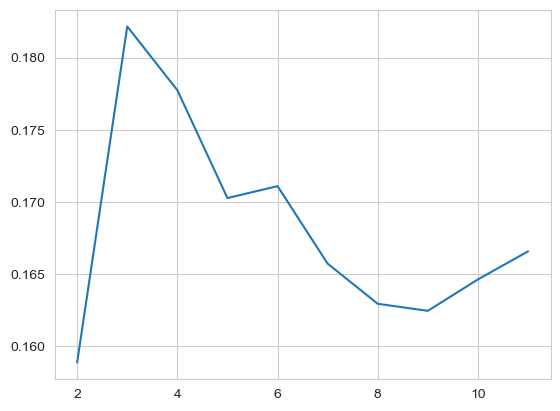

In [90]:
sns.lineplot(x = K, y = score)

In [91]:
nclusters = 3
kmeans = KMeans(n_clusters = nclusters, random_state = 0, n_init='auto')
kmeans.fit(df_norm[vars_plant])

KMeans(n_clusters=3, random_state=0)

In [92]:
unique, counts = np.unique(kmeans.labels_, return_counts=True)
unique
counts

array([429, 599, 572])

In [93]:
alive_means = [df_norm.loc[kmeans.labels_ == i, 'alive'].mean() for i in range(nclusters)]
alive_means

[0.2540792540792541, 0.2570951585976628, 0.2395104895104895]

In [94]:
import matplotlib.colors
cvals  = [0.5,  1]
colors = ["red","tab:blue"]

norm=plt.Normalize(min(cvals),max(cvals))
tuples = list(zip(map(norm,cvals), colors))
cmap = matplotlib.colors.LinearSegmentedColormap.from_list("", tuples)

/var/folders/9r/97b9zk_j4ys8v5lnksc4l4j00000gq/T/ipykernel_90240/3758073572.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(counts)
/var/folders/9r/97b9zk_j4ys8v5lnksc4l4j00000gq/T/ipykernel_90240/3758073572.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(counts)
/var/folders/9r/97b9zk_j4ys8v5lnksc4l4j00000gq/T/ipykernel_90240/3758073572.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(counts)
/var/folders/9r/97b9zk_j4ys8v5lnksc4l4j00000gq/T/ipykernel_90240/3758073572.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(counts)
/var/folders/9r/97b9zk_j4ys8v5lnksc4l4j00000

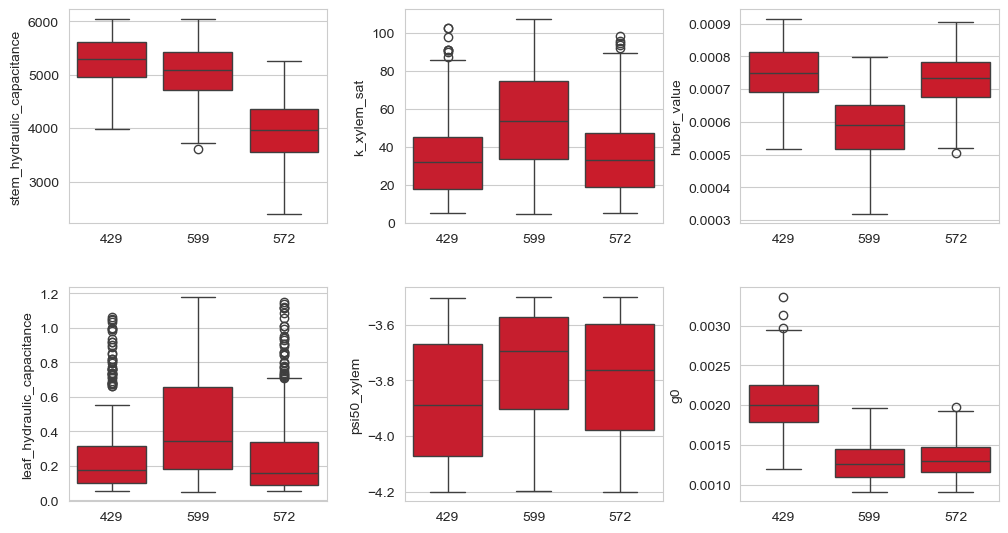

In [95]:
fig = plt.figure(figsize = (12,10))
for index,  var in zip(np.arange(1, len(vars_plant)+1), vars_plant):
    ax = fig.add_subplot(3,3, index)
    ax.set_xticklabels(counts)
    
    sns.boxplot(x = kmeans.labels_, y = df[var], ax=ax)
    for i in range(nclusters):
        box = ax.patches[i]
        box.set_facecolor(cmap(alive_means[i]))
fig.subplots_adjust(wspace=0.3, hspace=0.3)

In [96]:
from sklearn.cluster import MeanShift
from sklearn import metrics

db = MeanShift(bandwidth=2).fit(df_norm[vars_plant])

labels = db.labels_

# Number of clusters in labels, ignoring noise if present.
n_clusters_ = len(set(labels)) - (1 if -1 in labels else 0)
n_noise_ = list(labels).count(-1)
print("Estimated number of clusters: %d" % n_clusters_)
print("Estimated number of noise points: %d" % n_noise_)
print(f"Silhouette Coefficient: {metrics.silhouette_score(df_norm[vars_plant], db.labels_,metric='euclidean'):.3f}")

alive_means = [df_norm.loc[labels == i, 'alive'].mean() for i in range(3)]
alive_means

Estimated number of clusters: 1
Estimated number of noise points: 0


ValueError: Number of labels is 1. Valid values are 2 to n_samples - 1 (inclusive)

/var/folders/9r/97b9zk_j4ys8v5lnksc4l4j00000gq/T/ipykernel_90240/3214112877.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(counts)


IndexError: list index out of range

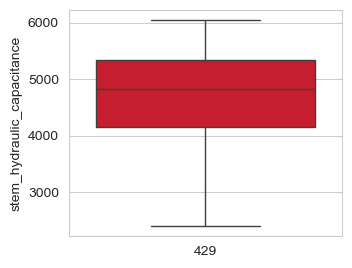

In [97]:
fig = plt.figure(figsize = (12,10))
for index,  var in zip(np.arange(1, len(vars_plant)+1), vars_plant):
    ax = fig.add_subplot(3,3, index)
    ax.set_xticklabels(counts)
    
    sns.boxplot(x = labels, y = df[var], ax=ax)
    for i in range(nclusters-1):
        box = ax.patches[i]
        box.set_facecolor(cmap(alive_means[i]))
fig.subplots_adjust(wspace=0.3, hspace=0.3)

In [98]:
from sklearn.cluster import HDBSCAN

In [99]:
db = HDBSCAN(min_cluster_size=4, cluster_selection_epsilon= 1).fit(df_norm[vars_plant])

labels = db.labels_

# Number of clusters in labels, ignoring noise if present.
n_clusters_ = len(set(labels)) - (1 if -1 in labels else 0)
n_noise_ = list(labels).count(-1)
print("Estimated number of clusters: %d" % n_clusters_)
print("Estimated number of noise points: %d" % n_noise_)
print(f"Silhouette Coefficient: {metrics.silhouette_score(df_norm[vars_plant], db.labels_,metric='euclidean'):.3f}")

alive_means = [df_norm.loc[labels == i, 'alive'].mean() for i in range(n_clusters_)]
alive_means

Estimated number of clusters: 2
Estimated number of noise points: 29
Silhouette Coefficient: 0.164


[0.24872122762148338, 0.2857142857142857]

In [100]:
labels.size

1600

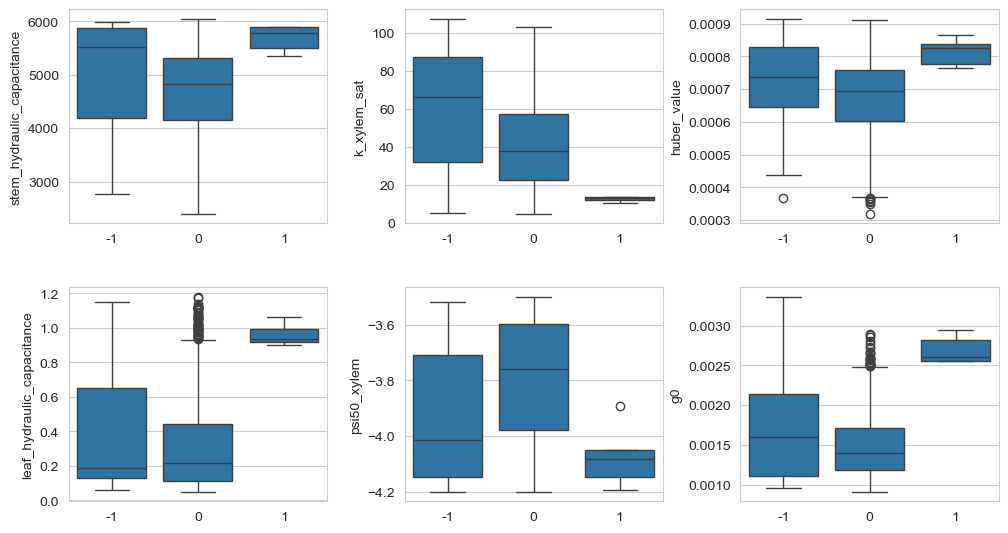

In [101]:
fig = plt.figure(figsize = (12,10))
for index,  var in zip(np.arange(1, len(vars_plant)+1), vars_plant):
    ax = fig.add_subplot(3,3, index)
    sns.boxplot(x = labels, y = df[var], ax=ax)
fig.subplots_adjust(wspace=0.3, hspace=0.3)

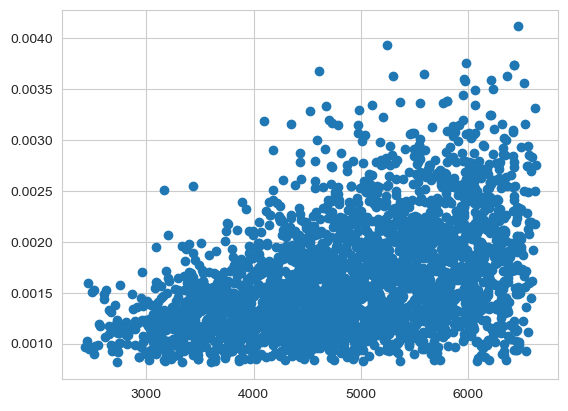

In [68]:
plt.scatter(df['stem_hydraulic_capacitance'], df['g0'])

<Axes: >

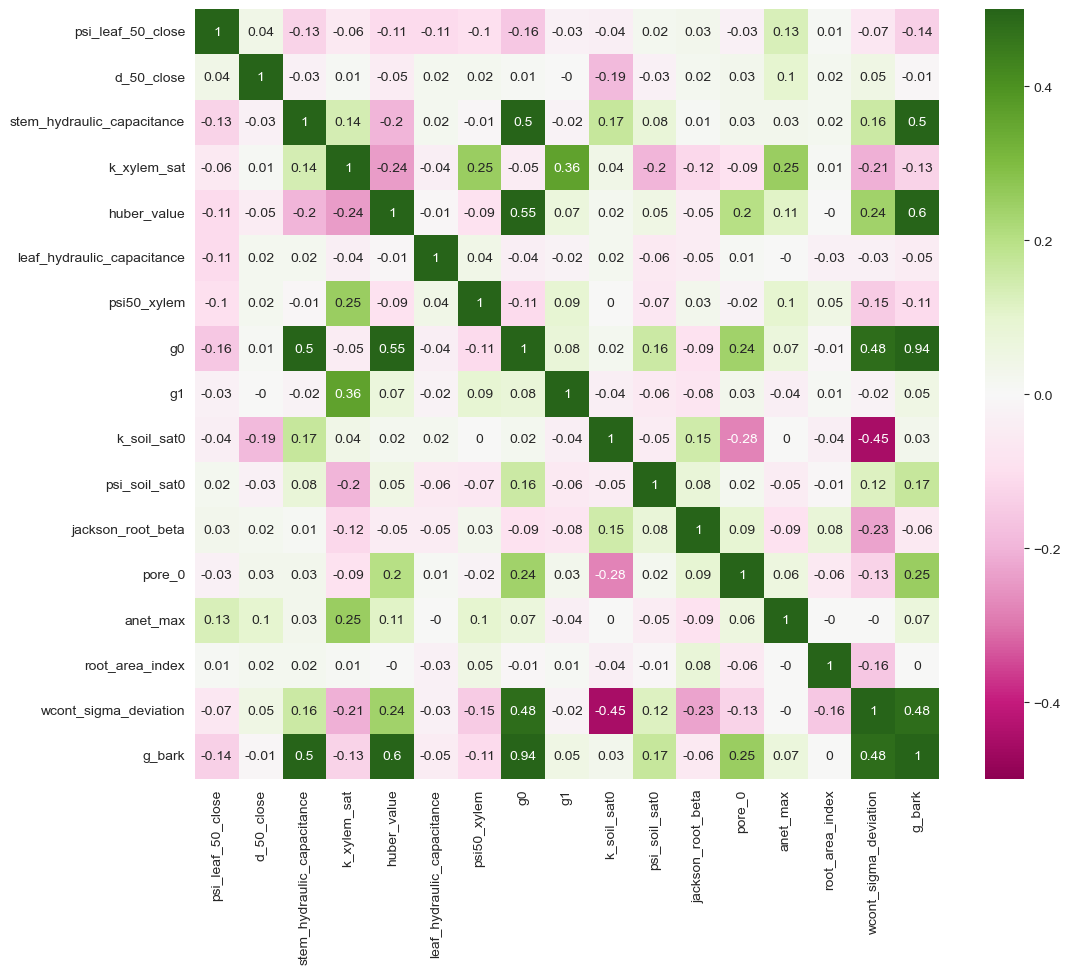

In [39]:
corr_matrix = df_mean.corr(method='spearman').round(2)
#corr_matrix.style.background_gradient(cmap='Greens')
plt.figure(figsize = (12,10))
sns.heatmap(corr_matrix, annot=True, vmin=-0.5, vmax=0.5, cmap="PiYG")